# Chamber Regrowth Analysis

This notebook analyzes survival outcomes across different coculture conditions in chamber experiments.

**Analysis includes:**
- Loading chamber survival data from Excel file
- Calculating survival statistics per coculture type
- Generating stacked bar charts (absolute counts and percentages)

**Outputs:**
- `3A_chamber_regrowth_stacked_counts.pdf`: Stacked bar chart showing chamber counts
- `3B_chamber_regrowth_stacked_percentages.pdf`: Stacked bar chart showing percentages

## Load and Prepare Data

Load chamber survival data from Excel file and display basic statistics

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the Excel file using relative path
file_path = 'chamber_regrowth.csv'
df = pd.read_csv(file_path)

# Clean the Survival column - remove leading/trailing whitespace
df['Survival'] = df['Survival'].str.strip()

# Display the dataframe to understand its structure
print("Data shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst few rows:")
df.head(10)
# PNAS figure style configuration
final_width_cm = 8.7  # Single column PNAS width
final_height_cm = 6
final_width_in = final_width_cm / 2.54
final_height_in = final_height_cm / 2.54
pnas_fontsize = 7

plt.rcParams.update({
    'font.size': pnas_fontsize,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'axes.linewidth': 0.75,
    'xtick.major.width': 0.75,
    'ytick.major.width': 0.75,
    'xtick.major.size': 3,
    'ytick.major.size': 3,
})

Data shape: (186, 4)

Column names:
['Coculture', 'Device', 'Chamber', 'Survival']

First few rows:


## Statistics

Display survival statistics for each coculture condition

In [3]:
# Get unique cocultures
unique_cocultures = df['Coculture'].unique()
print(f"Found {len(unique_cocultures)} cocultures:")
for i, cc in enumerate(unique_cocultures, 1):
    counts = df[df['Coculture'] == cc]['Survival'].value_counts()
    total = len(df[df['Coculture'] == cc])
    print(f"{i}. {cc}: {total} chambers total")
    for survival_type, count in counts.items():
        print(f"   - {survival_type}: {count} ({count/total*100:.1f}%)")

Found 5 cocultures:
1. S. aureus: 68 chambers total
   - no: 65 (95.6%)
   - yes: 3 (4.4%)
2. WT: 29 chambers total
   - yes: 26 (89.7%)
   - no: 3 (10.3%)
3. ∆rhlA: 29 chambers total
   - yes: 29 (100.0%)
4. ∆pqsL: 30 chambers total
   - no: 29 (96.7%)
   - yes: 1 (3.3%)
5. ∆rhlA ∆pqsL: 30 chambers total
   - no: 28 (93.3%)
   - yes: 2 (6.7%)


## Plot Stacked Bar Chart - Absolute Counts

Generate stacked bar chart showing the number of chambers with/without survival for each coculture

Figure saved as: 3A_chamber_regrowth_stacked_counts.pdf


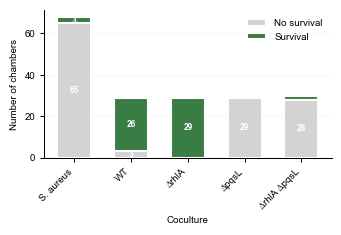


SURVIVAL SUMMARY BY COCULTURE (COUNTS)

S. aureus:
  Total chambers: 68
  Survival: 3
  No survival: 65

WT:
  Total chambers: 29
  Survival: 26
  No survival: 3

∆rhlA:
  Total chambers: 29
  Survival: 29
  No survival: 0

∆pqsL:
  Total chambers: 30
  Survival: 1
  No survival: 29

∆rhlA ∆pqsL:
  Total chambers: 30
  Survival: 2
  No survival: 28


In [4]:
# Colorblind-friendly palette
color_survival = '#3a7d44'  # Green for survival (positive outcome)
color_no_survival = '#d3d3d3'  # Light grey for no survival

# Get unique cocultures
cocultures = df['Coculture'].unique()

# Prepare data for stacked bar chart - COUNTS
survival_counts = []
no_survival_counts = []
labels = []

for cc in cocultures:
    df_cc = df[df['Coculture'] == cc]
    
    # Count survival outcomes
    yes_count = len(df_cc[df_cc['Survival'] == 'yes'])
    no_count = len(df_cc[df_cc['Survival'] == 'no'])
    
    # Store counts
    survival_counts.append(yes_count)
    no_survival_counts.append(no_count)
    labels.append(cc)

# Create figure
fig, ax = plt.subplots(figsize=(final_width_in, final_height_in))

# Create stacked bar chart
x = np.arange(len(labels))
bar_width = 0.6

# Plot stacked bars using COUNTS
p1 = ax.bar(x, no_survival_counts, bar_width, 
            label='No survival', color=color_no_survival, 
            edgecolor='white', linewidth=1.5)
p2 = ax.bar(x, survival_counts, bar_width, bottom=no_survival_counts,
            label='Survival', color=color_survival,
            edgecolor='white', linewidth=1.5)

# Customize axes
ax.set_ylabel('Number of chambers', fontsize=pnas_fontsize)
ax.set_xlabel('Coculture', fontsize=pnas_fontsize)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=pnas_fontsize)

# Add count labels on bars
for i, (no_val, yes_val) in enumerate(zip(no_survival_counts, survival_counts)):
    # Label for no survival (bottom bar)
    if no_val > 2:  # Only show if segment is large enough
        ax.text(i, no_val/2, f'{no_val}', 
                ha='center', va='center', 
                color='white', fontsize=pnas_fontsize-1, fontweight='bold')
    
    # Label for survival (top bar)
    if yes_val > 2:  # Only show if segment is large enough
        ax.text(i, no_val + yes_val/2, f'{yes_val}', 
                ha='center', va='center',
                color='white', fontsize=pnas_fontsize-1, fontweight='bold')

# Apply Chartosaur styling
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='upper right', frameon=False, fontsize=pnas_fontsize)
ax.grid(True, axis='y', alpha=0.2, linewidth=0.5, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()

# Save figure with relative path
save_path = '3A_chamber_regrowth_stacked_counts.pdf'
plt.savefig(save_path, format='pdf', dpi=300, bbox_inches='tight')
print(f"Figure saved as: {save_path}")

plt.show()

# Print summary statistics
print(f"\n{'='*60}")
print(f"SURVIVAL SUMMARY BY COCULTURE (COUNTS)")
print(f"{'='*60}")
for i, cc in enumerate(labels):
    total = len(df[df['Coculture'] == cc])
    print(f"\n{cc}:")
    print(f"  Total chambers: {total}")
    print(f"  Survival: {survival_counts[i]}")
    print(f"  No survival: {no_survival_counts[i]}")
print(f"{'='*60}")

## Plot Stacked Bar Chart - Percentages

Generate stacked bar chart showing the percentage of chambers with/without survival for each coculture

Figure saved as: 3B_chamber_regrowth_stacked_percentages.pdf


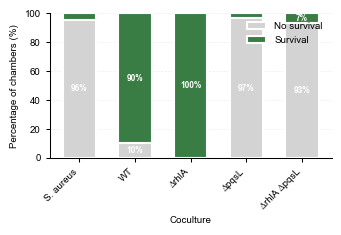


SURVIVAL SUMMARY BY COCULTURE (PERCENTAGES)

S. aureus:
  Total chambers: 68
  Survival: 4.4%
  No survival: 95.6%

WT:
  Total chambers: 29
  Survival: 89.7%
  No survival: 10.3%

∆rhlA:
  Total chambers: 29
  Survival: 100.0%
  No survival: 0.0%

∆pqsL:
  Total chambers: 30
  Survival: 3.3%
  No survival: 96.7%

∆rhlA ∆pqsL:
  Total chambers: 30
  Survival: 6.7%
  No survival: 93.3%


In [5]:
# Colorblind-friendly palette
color_survival = '#3a7d44'  # Green for survival (positive outcome)
color_no_survival = '#d3d3d3'  # Light grey for no survival

# Get unique cocultures
cocultures = df['Coculture'].unique()

# Prepare data for stacked bar chart - PERCENTAGES
survival_pct = []
no_survival_pct = []
labels = []

for cc in cocultures:
    df_cc = df[df['Coculture'] == cc]
    total = len(df_cc)
    
    # Count survival outcomes
    yes_count = len(df_cc[df_cc['Survival'] == 'yes'])
    no_count = len(df_cc[df_cc['Survival'] == 'no'])
    
    # Calculate percentages
    survival_pct.append(yes_count / total * 100)
    no_survival_pct.append(no_count / total * 100)
    labels.append(cc)

# Create figure
fig, ax = plt.subplots(figsize=(final_width_in, final_height_in))

# Create stacked bar chart
x = np.arange(len(labels))
bar_width = 0.6

# Plot stacked bars using PERCENTAGES
p1 = ax.bar(x, no_survival_pct, bar_width, 
            label='No survival', color=color_no_survival, 
            edgecolor='white', linewidth=1.5)
p2 = ax.bar(x, survival_pct, bar_width, bottom=no_survival_pct,
            label='Survival', color=color_survival,
            edgecolor='white', linewidth=1.5)

# Customize axes
ax.set_ylabel('Percentage of chambers (%)', fontsize=pnas_fontsize)
ax.set_xlabel('Coculture', fontsize=pnas_fontsize)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=pnas_fontsize)
ax.set_ylim(0, 100)

# Add percentage labels on bars
for i, (no_val, yes_val) in enumerate(zip(no_survival_pct, survival_pct)):
    # Label for no survival (bottom bar)
    if no_val > 5:  # Only show if segment is large enough
        ax.text(i, no_val/2, f'{no_val:.0f}%', 
                ha='center', va='center', 
                color='white', fontsize=pnas_fontsize-1, fontweight='bold')
    
    # Label for survival (top bar)
    if yes_val > 5:  # Only show if segment is large enough
        ax.text(i, no_val + yes_val/2, f'{yes_val:.0f}%', 
                ha='center', va='center',
                color='white', fontsize=pnas_fontsize-1, fontweight='bold')

# Apply Chartosaur styling
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='upper right', frameon=False, fontsize=pnas_fontsize)
ax.grid(True, axis='y', alpha=0.2, linewidth=0.5, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()

# Save figure with relative path
save_path = '3B_chamber_regrowth_stacked_percentages.pdf'
plt.savefig(save_path, format='pdf', dpi=300, bbox_inches='tight')
print(f"Figure saved as: {save_path}")

plt.show()

# Print summary statistics
print(f"\n{'='*60}")
print(f"SURVIVAL SUMMARY BY COCULTURE (PERCENTAGES)")
print(f"{'='*60}")
for i, cc in enumerate(labels):
    total = len(df[df['Coculture'] == cc])
    print(f"\n{cc}:")
    print(f"  Total chambers: {total}")
    print(f"  Survival: {survival_pct[i]:.1f}%")
    print(f"  No survival: {no_survival_pct[i]:.1f}%")
print(f"{'='*60}")